# Working with Images in Python

In this notebook, we will learn how Python represents images.

We will start with a **black-and-white (grayscale)** image, then move to a **color image**, and see that a color image is essentially three grayscale images stacked together.

## Learning goals
- understand how grayscale images are stored as arrays
- understand how color images are stored as three channels (or three arrays)
- visualize pixel values
- manipulate brightness and contrast
- isolate color channels
- make simple image edits in Python

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#PIL is the official Python library for Image manipulation. Another alternative is OpenCV
from PIL import Image 

A grayscale image is defined by an array with values that range between 0 and 255. 

Each value in the array represents a pixel in the image, and the value is the color intensity. 
0 -> Black 
255 -> White

Values between 0 and 255 are different intensities of gray; low values are darker than higher values. 

In [33]:
# Create a small grayscale image manually
# Values go from 0 (black) to 255 (white)
gray_array = np.array([
    [0, 50, 100, 150, 200],
    [25, 75, 125, 175, 225],
    [50, 100, 150, 200, 250],
    [75, 125, 175, 225, 255],
    [100, 150, 200, 230, 255]
], dtype=int)

print('Shape:', gray_array.shape)

Shape: (5, 5)


To visualize the image, we can use matplotlib function `imshow`. 

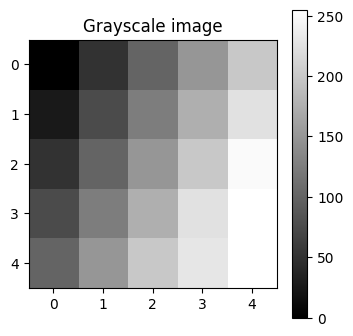

In [23]:
plt.figure(figsize=(4, 4))
plt.imshow(gray_array, cmap='gray', vmin=0, vmax=255)
plt.title('Grayscale image')
plt.colorbar()
plt.show()

Because it is an array, we can acces the individual values using indexing

In [8]:
print('Pixel at row 0, col 0:', gray_array[0, 0])
print('Pixel at row 2, col 3:', gray_array[2, 3])
print('Pixel at row 4, col 4:', gray_array[4, 4])

Pixel at row 0, col 0: 0
Pixel at row 2, col 3: 200
Pixel at row 4, col 4: 255


## Activity

Perform the following modification to the image, visualize each modification in turn. 

- make the center pixel black
- make the top row all white
- create a diagonal bright line

You can modify the color intensity by adjusting the values of each `pixel`. Rember that values must be between 0 and 255, so we must ensure that the values are within those limits. 

The numpy function `clip` is useful for this

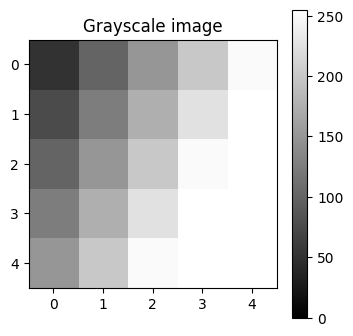

In [25]:
#make the image brighter by increasing the values 
bright_image = np.clip(gray_array+50, 0, 255)
plt.figure(figsize=(4, 4))
plt.imshow(bright_image, cmap='gray', vmin=0, vmax=255)
plt.title('Grayscale image')
plt.colorbar()
plt.show()

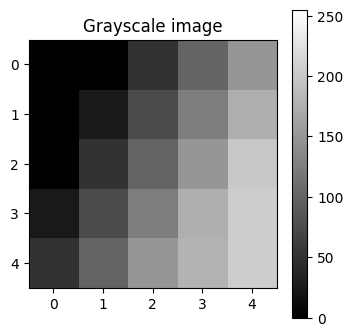

In [26]:
#make the image darker by decreasing the values 
darker_image = np.clip(gray_array-50, 0, 255)
plt.figure(figsize=(4, 4))
plt.imshow(darker_image, cmap='gray', vmin=0, vmax=255)
plt.title('Grayscale image')
plt.colorbar()
plt.show()



## How is a color image represented?

A color image is a **3D array**.

Its shape is usually:

`(height, width, 3)`

The last dimension stores three channels:
- channel 0 = red
- channel 1 = green
- channel 2 = blue

So a color image is basically **three grayscale images stacked together**, one for each color channel.

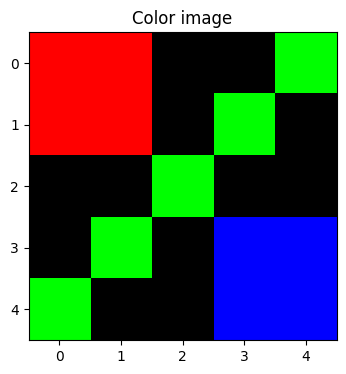

In [44]:

red_channel = np.array([
    [255, 255, 0, 0, 0],
    [255, 255, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0]
], dtype=int)

green_channel = np.array([
    [0, 0, 0, 0, 255],
    [0, 0, 0, 255, 0],
    [0, 0, 255, 0, 0],
    [0, 255, 0, 0, 0],
    [255, 0, 0, 0, 0]
], dtype=int)

blue_channel = np.array([
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 255, 255],
    [0, 0, 0, 255, 255]
], dtype=int)

#the color image is formed by stacking these channels together 
color_image = np.stack([red_channel, green_channel, blue_channel], axis=2)
plt.figure(figsize=(4, 4))
plt.imshow(color_image)
plt.title('Color image')
plt.show()

And you can combine colors to create new colors 

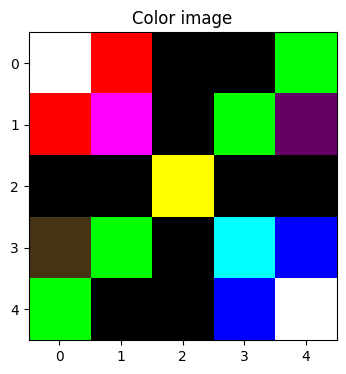

In [54]:
red_channel = np.array([
    [255, 255, 0, 0, 0],
    [255, 255, 0, 0, 100],
    [0, 0, 255, 0, 0],
    [70, 0, 0, 0, 0],
    [0, 0, 0, 0, 255]
], dtype=int)

green_channel = np.array([
    [255, 0, 0, 0, 255],
    [0, 0, 0, 255, 0],
    [0, 0, 255, 0, 0],
    [50, 255, 0, 255, 0],
    [255, 0, 0, 0, 255]
], dtype=int)

blue_channel = np.array([
    [255, 0, 0, 0, 0],
    [0, 255, 0, 0, 100],
    [0, 0, 0, 0, 0],
    [20, 0, 0, 255, 255],
    [0, 0, 0, 255, 255]
], dtype=int)

#the color image is formed by stacking these channels together 
color_image = np.stack([red_channel, green_channel, blue_channel], axis=2)
plt.figure(figsize=(4, 4))
plt.imshow(color_image)
plt.title('Color image')
plt.show()

## Activity
Create a new `5 x 5 x 3` image and make your own pattern.

Ideas:
- draw a red horizontal line
- draw a blue diagonal
- make the center bright white
- Create a checkerboard with two colors

You can load your custom images using PIL and manipulate them within Python

(408, 612, 3)


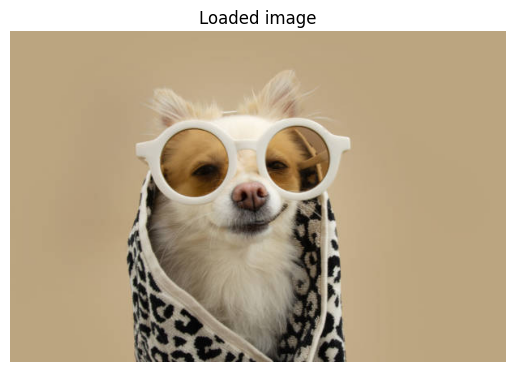

In [69]:
image = Image.open('data/sample_image.jpg')
image_array = np.array(image)
print(image_array.shape)
plt.imshow(image_array)
plt.title('Loaded image')
plt.axis('off')
plt.show()

This is an array with 408 rows, 612 columns, and three channels. 

You can also visualize each channel independently:

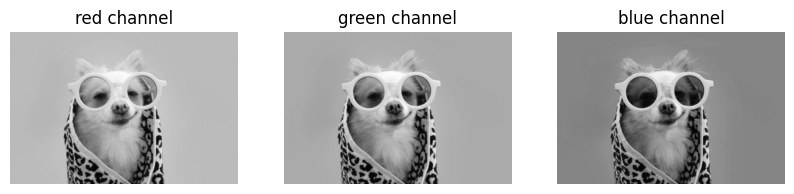

In [66]:
plt.figure(figsize=(10, 3))
plt.subplot(1, 3, 1)
plt.imshow(image_array[:,:,0], cmap='gray')
plt.title('red channel')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(image_array[:,:,1], cmap='gray')
plt.title('green channel')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(image_array[:,:,2], cmap='gray')
plt.title('blue channel')
plt.axis('off')

plt.show()

Let's turn off one of the channels and see what happens.

(408, 612, 3)


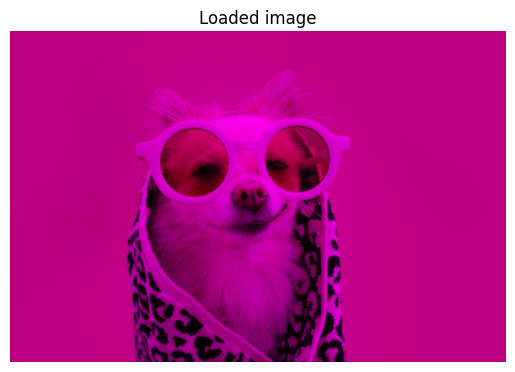

In [71]:
mod_image = image_array.copy()
mod_image[:,:,1] = 0
print(mod_image.shape)
plt.imshow(mod_image)
plt.title('Loaded image')
plt.axis('off')
plt.show()

Some common transformations 

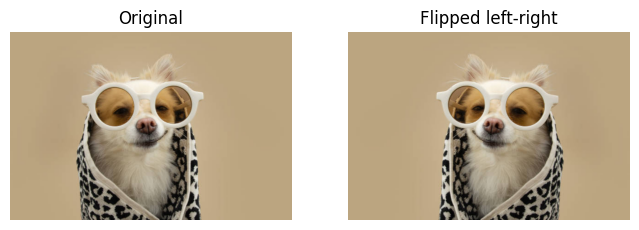

In [74]:
#flip image 
flipped = np.fliplr(image_array)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(flipped)
plt.title('Flipped left-right')
plt.axis('off')
plt.show()

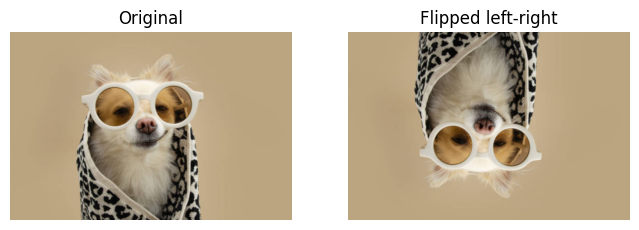

In [76]:
#flip image 
flipped = np.flipud(image_array)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(flipped)
plt.title('Flipped up-down')
plt.axis('off')
plt.show()

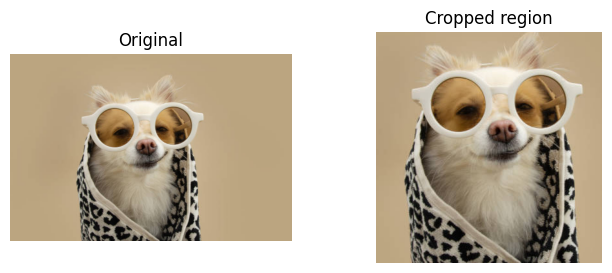

In [81]:
#crop the image 
cropped = image_array[50:450, 100:450,:]

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cropped)
plt.title('Cropped region')
plt.axis('off')
plt.show()